# <center>Performances et optimisation de métaheuristique<br /> Workshop</center>
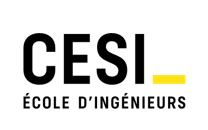

# 1. Introduction
Nous reprenons pour la dernière fois le problème du [sac à dos](https://fr.wikipedia.org/wiki/Probl%C3%A8me_du_sac_%C3%A0_dos), et on va chercher à savoir si les algorithmes qu'on a conçus sont efficaces


Commencez par intégrer le code de la recherche tabou que vous avez conçue la dernière fois.

In [11]:
from collections import deque
import random
from functools import lru_cache

def random_objets(poids_max, val_max):
    """
    Cette fonction génère des objets de poids et de valeur
    aléatoires (bornés par les valeurs passées en parametre).
    
    Renvoie un tuple de 2 dictionnaires (poids,valeur)
    """
    # A COMPLETER

def random_solution():
    # A COMPLETER

def poids_contenu(sac):
    """
    Cette fonction renvoie la somme des poids des objets dans le sac
    """
    # A COMPLETER

def valeur_contenu(sac):
    """
    Cette fonction renvoie la somme des valeurs des objets dans le sac
    """
    # A COMPLETER

def voisinage(sac):
    # A COMPLETER

def hill_climbing(solution_initiale):
    """
    1. On part d'un élément de notre ensemble de recherche qu'on déclare élément courant
    2. On considere le voisinage de l'élément courant et on choisit le  meilleur d'entre
       eux comme nouvel élément courant
    3. On boucle jusqu'à convergence sur un optimum local
    """

    # A COMPLETER

def recherche_tabou(solution_initiale, taille_tabou, iter_max):
    """
    1. On part d'un élément de notre ensemble de recherche qu'on déclare élément courant
    2. On considère le voisinage de l'element courant et on choisit le  meilleur d'entre
       eux comme nouvel element courant, parmi ceux absents de la liste tabou, et on l'ajoute
       a la liste tabou
    3. On boucle jusqu'a condition de sortie.
    """
    # A COMPLETER


Relançons nos méthodes !

In [6]:
nb_objets = 100
capacite = 20

In [10]:
import random

random.seed(a=3)
poids_objets, valeur_objets = random_objets(10, 10)

In [ ]:
sac = (False,)*nb_objets

sol_HC = # A COMPLETER
print("Solution Hill Climbing")
print("valeur finale = " + str(valeur_contenu(sol_HC)) + ", capacite=" + str(poids_contenu(sol_HC)) + "/" + str(capacite))
print([i for i, val in enumerate(sol_HC) if val]) # liste des objets dans le sac

print("Solution Tabu Search [tabou de taille 5]")
sol_TS = # A COMPLETER
print("valeur finale = " + str(valeur_contenu(sol_TS)) + ", capacite="+str(poids_contenu(sol_TS)) + "/" + str(capacite))
print([i for i, val in enumerate(sol_TS) if val]) # composition de la solution

Solution Hill Climbing
valeur finale = 30, capacite=20/20
[5, 11, 27]
Solution Tabu Search
tabou de taille 5
valeur finale = 62, capacite=20/20
[24, 27, 30, 41, 44, 45, 62]


# 2. Comportement de l'algorithme

Avec notre algorithme, on obtient une solution réalisable, mais on ne sait pas vraiment comment l'algorithme l'a obtenue. Difficile dans ces conditions d'imaginer ce qu'on pourrait faire pour améliorer la solution obtenue. Essayons déjà de voir comment l'algorithme arrive à ce résultat.

## 2.1 Étude de la trajectoire

Commençons par étudier la trajectoire que suit notre algorithme. C'est assez simple, il suffit de retenir toutes les solutions courantes et l'historique des meilleures solutions trouvées à chaque itération, et d'afficher tout ça avec [matplotlib](https://matplotlib.org/index.html). Allons-y !



In [1]:
import matplotlib.pyplot as plt

In [17]:
def hill_climbing_traject(solution_initiale):
    """
    1. On part d'un élément de notre ensemble de recherche qu'on déclare élément courant
    2. On considere le voisinage de l'élément courant et on choisit le  meilleur d'entre
       eux comme nouvel élément courant
    3. On boucle jusqu'à convergence sur un optimum local
    """

    solution_courante = solution_initiale
    nouveau = True
    nb_iter = 0 # uniquement utilisé pour l'affichage

    # liste des solutions courantes et des meilleures trouvées, pour afficher la trajectoire
    # l'élément à la ième position correspond à l'itération i
    
    courantes = # A COMPLETER
    meilleures_courantes = # A COMPLETER
    
    while (nouveau):
        nb_iter += 1
        meilleure_solution = solution_courante
        # on parcourt tous les voisins de la solution courante pour garder la meilleure
        for voisin in voisinage(solution_courante): 
            if valeur_contenu(voisin) > valeur_contenu(meilleure_solution): 
                meilleure_solution = voisin
                
        nouveau = (meilleure_solution != solution_courante)
        solution_courante = meilleure_solution

        courantes.append(# A COMPLETER
        meilleures_courantes.append(# A COMPLETER

    return solution_courante, courantes, meilleures_courantes

In [4]:
def recherche_tabou_traject(solution_initiale, taille_tabou, iter_max):
    """
    1. On part d'un élément de notre ensemble de recherche qu'on déclare élément courant
    2. On considère le voisinage de l'élément courant, on choisit le meilleur d'entre
       eux comme nouvel élément courant parmi ceux absents de la liste tabou, et on l'ajoute
       à la liste tabou
    3. On boucle jusqu'à condition de sortie.
    """
    nb_iter = 0
    liste_tabou = deque((), maxlen = taille_tabou)

    # variables solutions pour la recherche du voisin optimal non tabou
    solution_courante = solution_initiale
    meilleure = solution_initiale
    meilleure_globale = solution_initiale

    # variables valeurs  pour la recherche du voisin optimal non tabou
    valeur_meilleure = valeur_contenu(solution_initiale)
    valeur_meilleure_globale = valeur_meilleure

    # variables pour l'affichage
    meilleure_trouvee = 0
    meilleure_globale_trouvee = 0
    
    # liste des solutions courantes et des meilleures trouvées, pour afficher la trajectoire
    # l'élément à la ième position correspond à l'itération i
    courantes = # A COMPLETER
    meilleures_courantes = # A COMPLETER
    
    while (nb_iter < iter_max):
        nb_iter += 1
        valeur_meilleure = 0
        
        # on parcourt tous les voisins de la solution courante
        for voisin in voisinage(solution_courante):
            valeur_voisin = valeur_contenu(voisin)                             #SOLUTION
                                                                               #SOLUTION
            # meilleure solution non taboue trouvée                            #SOLUTION
            if valeur_voisin > valeur_meilleure and voisin not in liste_tabou: #SOLUTION
                meilleure_trouvee += 1                                         #SOLUTION
                valeur_meilleure = valeur_voisin                               #SOLUTION
                meilleure = voisin                                             #SOLUTION
        
        # on met à jour la meilleure solution rencontrée depuis le début
        if valeur_meilleure > valeur_meilleure_globale:
            meilleure_globale_trouvee += 1
            meilleure_globale = meilleure
            valeur_meilleure_globale = valeur_meilleure
            nb_iter = 0
        
        meilleures_courantes.append(# A COMPLETER
        courantes.append(# A COMPLETER
        
        # on passe au meilleur voisin non tabou trouvé
        solution_courante = meilleure
        
        # on met à jour la liste tabou
        liste_tabou.append(solution_courante)   #SOLUTION

    return meilleure_globale, courantes, meilleures_courantes

Testons ça ! 

In [20]:
def afficher_courbe(courants, meilleurs_courants, title): 
    plt.figure()
    plt.plot(range(len(courants)), courants, label="Solution courante")
    plt.plot(range(len(meilleurs_courants)), meilleurs_courants, label="Meilleure solution")
    plt.xlabel("Nombre d'itérations", fontsize=16)
    plt.ylabel("Valeur", fontsize=16)
    plt.title(title)
    plt.legend()
    plt.grid()

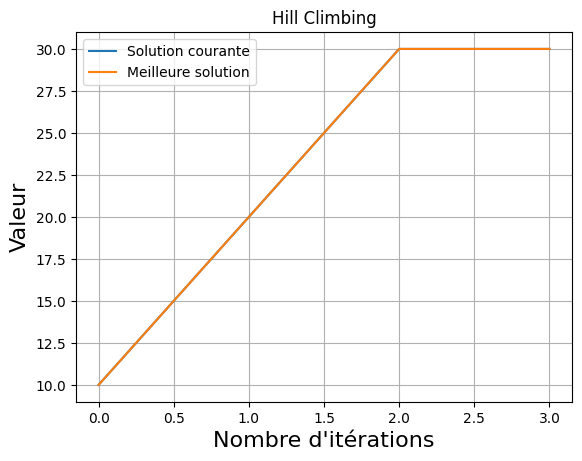

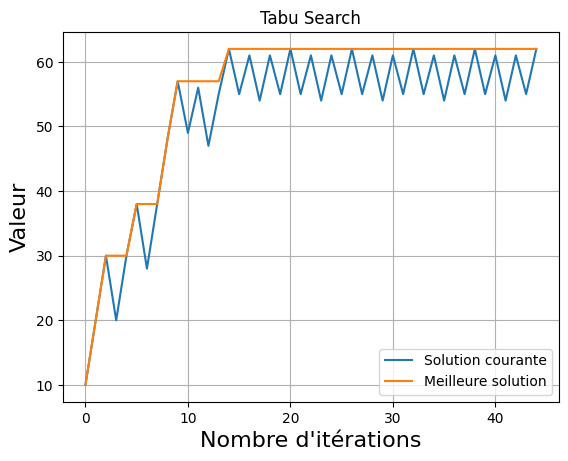

In [ ]:
sac = (False,)*nb_objets
    
# Hill Climbing 
sol_HC, courants_HC, meilleurs_courants_HC = # A COMPLETER
afficher_courbe(courants_HC, meilleurs_courants_HC, "Hill Climbing")

# Tabu Search 
iter_max = 30
taille_tabou = 5
sol_TS, courants_TS, meilleurs_courants_TS = # A COMPLETER
afficher_courbe(courants_TS, meilleurs_courants_TS, "Tabu Search")


On observe un phénomène intéressant au bout d'un certain temps. Comment s'appelle-t-il ? 

<em>À COMPLÉTER</em>

Question 1 : Comment s'appelle le phénomène où la Recherche Tabou oscille entre des solutions proches sans progresser ?

1. Une divergence algorithmique
2. Un cycle dans le bassin d'attraction d'un optimum local
3. Une explosion combinatoire
4. Une convergence prématurée vers l'optimum global

In [ ]:
Q1 = # A COMPLETER

Question 2 : Qu'est-ce que le bassin d'attraction d'un optimum local ?

1. L'ensemble de toutes les solutions réalisables du problème
2. La région de l'espace de recherche depuis laquelle l'algorithme converge vers cet optimum local
3. La liste des mouvements interdits autour de l'optimum local
4. L'ensemble des solutions ayant une valeur strictement meilleure que l'optimum local

In [ ]:
Q2 = # A COMPLETER

Question 3 : Que traduit le fait que l'algorithme oscille dans un bassin d'attraction ?

1. Que la liste tabou est trop longue et interdit trop de mouvements
2. Que la fonction objectif est mal définie
3. Que l'intensification domine trop et que la diversification est insuffisante pour s'échapper de l'optimum local
4. Que le voisinage choisi est trop grand

In [ ]:
Q3 = # A COMPLETER

Question 4 : Quelle est la première solution envisagée pour s'échapper d'un bassin d'attraction ?

1. Réduire le nombre d'itérations de l'algorithme
2. Augmenter la taille de la liste tabou pour interdire davantage de mouvements déjà explorés
3. Relancer l'algorithme depuis la solution initiale
4. Réduire la taille du voisinage exploré à chaque itération

In [ ]:
Q4 = # A COMPLETER


Testons cette solution (avec une valeur de 200, par exemple) :

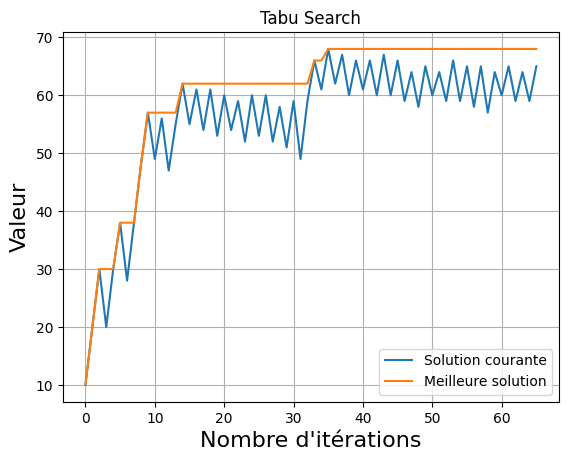

In [24]:
sac=(False,)*nb_objets
taille_tabou = # A COMPLETER

sol_TS, courants_TS, meilleurs_courants_TS = recherche_tabou_traject(sac, taille_tabou, iter_max)
afficher_courbe(courants_TS, meilleurs_courants_TS, "Tabu Search")

Question 5 : Qu'indique le fait que la meilleure solution est trouvée vers la 30ème itération, puis que les solutions régressent longuement avant d'y revenir ?

1. Que l'algorithme manque de diversification et reste prisonnier d'un second bassin d'attraction plus large
2. Que la fonction objectif présente une discontinuité autour de la meilleure solution
3. Que la liste tabou est trop longue et empêche l'algorithme de progresser
4. Que la solution initiale était déjà un optimum local

In [ ]:
Q5 = # A COMPLETER

Essayons donc d'augmenter encore la valeur.

In [ ]:
sac=(False,)*nb_objets
taille_tabou = # A COMPLETER

sol_TS, courants_TS, meilleurs_courants_TS = recherche_tabou_traject(sac, taille_tabou, iter_max)
afficher_courbe(courants_TS, meilleurs_courants_TS, "Tabu Search")

Le résultat est identique à celui obtenu précédemment.

Question 6 : Que proposez-vous pour y remédier ?

1. Réduire la taille de la liste tabou pour accélérer la convergence
2. Augmenter également le nombre d'itérations pour laisser le temps à la liste tabou de se remplir
3. Changer la solution initiale pour relancer la recherche depuis un autre point
4. Réduire le voisinage pour limiter le nombre de mouvements explorés à chaque itération

In [ ]:
Q6 = # A COMPLETER

Essayons avec la même valeur que pour la taille de la liste.

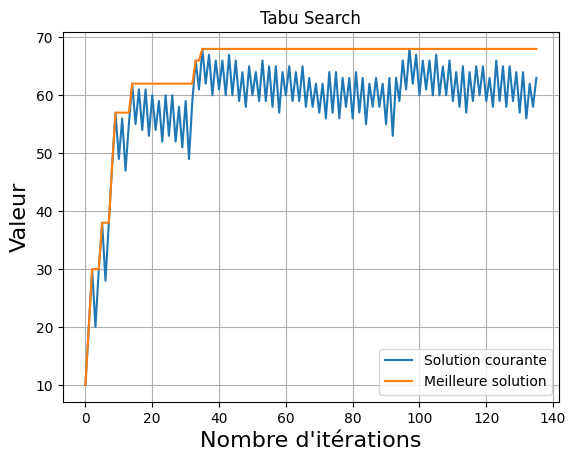

In [25]:
sac=(False,)*nb_objets
iter_max = # A COMPLETER

sol_TS, courants_TS, meilleurs_courants_TS = recherche_tabou_traject(sac, taille_tabou, iter_max)
afficher_courbe(courants_TS, meilleurs_courants_TS, "Tabu Search")

Qu'observe-t-on ?

<em>À COMPLÉTER</em>


## 2.2 Qualité de la solution

Mais finalement, on ne sait pas si cette solution que notre algorithme génère est vraiment bonne. On sait qu'on l'a améliorée depuis le Hill-Climbing, et qu'on peut faire mieux, puisque le multi-start y arrive. Or, la question risque d'être difficile à trancher. 

Question 6 : Pourquoi ?

1. Car la métaheuristique ne conserve pas la meilleure solution trouvée au fil des itérations
2. Car le problème est NP-Difficile, ce qui rend le calcul de la solution optimale impossible en temps raisonnable pour une grande instance
3. Car la fonction objectif est trop complexe à évaluer
4. Car le voisinage choisi ne couvre pas tout l'espace des solutions

Mais on pourrait quand même essayer de trouver un point de comparaison, moins précis, mais qui nous apporte quand même quelques informations. Et la solution est en fait très simple, elle se retrouve dans le Workshop sur la programmation linéaire. Souvenez-vous, on avait déjà travaillé sur le problème du sac à dos. Est-ce qu'on avait réussi à le résoudre ? Pourquoi ?

<em>À COMPLÉTER</em>


Question 7 : Et que produisait la méthode de résolution qu'on avait essayé de mettre en place ?

1. Une solution réalisable
2. Une solution optimale 
3. Une borne inférieure 
3. Une borne supérieure

In [ ]:
Q7 = # A COMPLETER

Question 8 : Pourquoi la solution produite par le Simplexe sur le problème du sac à dos est-elle une borne supérieure de l'optimal ?

1. Car le Simplexe surestime toujours la valeur des objets
2. Car en ignorant la contrainte d'intégrité des variables, l'espace des solutions admissibles est élargi, ce qui permet d'atteindre une valeur meilleure que l'optimal entier
3. Car le Simplexe explore toutes les solutions possibles avant de s'arrêter
4. Car la relaxation continue ajoute des contraintes supplémentaires au problème

In [ ]:
Q8 = # A COMPLETER

Le voilà notre indicateur ! Grace à ça, on va pouvoir mettre en place un [plan d'expériences](https://fr.wikipedia.org/wiki/Plan_d%27exp%C3%A9riences) (inutile par contre d'appliquer directement les principes mathématiques mentionnés dans ce lien, ils sont juste là pour vous donner une idée du principe général et sont des outils rarement utilisés tel quel dans le domaine de l'évaluation d'algorithmes).


Question 9 : Si la solution de la métaheuristique est proche de la borne supérieure, que peut-on conclure ?

1. Que la solution est nécessairement optimale
2. Que la borne supérieure est mal calculée
3. Que la solution est de bonne qualité, car peu d'amélioration est possible entre elle et l'optimum
4. Que l'algorithme a convergé trop rapidement

In [ ]:
Q9 = # A COMPLETER

Il ne nous reste plus qu'à reprendre le code de la programmation linéaire (workshop 3). Testons ça :

In [26]:
# on vous donne la solution toute faite !

from pulp import *

def borne_superieure():
    objets = range(nb_objets)

    # variables
    x = LpVariable.dicts('objet', objets, 0, 1)
    
    # probleme
    prob = LpProblem("knapsack", LpMaximize)

    # fonction objective
    cost = lpSum([valeur_objets[i]*x[i] for i in objets])
    prob += cost

    # contrainte
    prob += lpSum([poids_objets[i]*x[i] for i in objets]) <= capacite

    prob.solve()
    return value(prob.objective) if (LpStatus[prob.status] == "Optimal") else None

borne = borne_superieure()
if borne is not None:
    print("borne supérieure : ", borne)
print("valeur de la solution :", str(valeur_contenu(sol_TS)))

borne supérieure :  91.33333329999999
valeur de la solution : 68


# 3. Plan d'expérience et optimisation de l'algorithme

On a réussi à construire une solution aux 2/3 de la borne (voire plus si on utilise le multi-start) de notre instance aléatoire. 

Question 10 : Est-ce qu'on peut généraliser ce résultat ?

1. Non, car une seule instance prend trop de temps à calculer
2. Non, Car le résultat obtenu peut être non représentatif, l'instance pouvant être particulièrement facile ou difficile
3. Oui, Car la métaheuristique produit toujours le même résultat sur la même instance
4. Non, Car la borne supérieure n'est valable que pour une instance spécifique

In [ ]:
Q10 = # A COMPLETER

## 3.1 Qualité statistique des solutions

Pour se faire une idée plus exacte des performances de l'algorithme, il faudrait tester un grand nombre d'instances.

Reprenons la taille de tabou et le nombre d'itérations qui ont donné de bons résultats tout à l'heure. Par ailleurs, pour essayer d'augmenter la représentativité de nos résultats, on va fournir à la recherche une solution initiale aléatoire à chaque test.

Et vu qu'on recommence à avoir des calculs qui prennent du temps, on va réutiliser la barre de progression du premier Workshop. Pour cette fois, le code vous est rappelé.

In [28]:
from ipywidgets import IntProgress
from IPython.display import display

random.seed(a=3)
bornes = deque(())

iter_max     = 200 #SOLUTION
taille_tabou = 100 #SOLUTION

# paramètres du test
nb_tests = 200

# on affiche la barre de progression
bar = IntProgress(min=0, max=nb_tests, layout={"width" : "100%"})
display(bar)

for _ in range(nb_tests):
    #À COMPLÉTER

    bornes.append(distance)
    bar.value += 1

# on cache la barre de progression
bar.close()

print(sum(bornes) / len(bornes))

IntProgress(value=0, layout=Layout(width='100%'), max=200)

15.4633333339


Regardons un peu plus en détail les valeurs qu'on obtient. Ça tombe bien, on a la liste de toutes les distances. 

Question 11 : Comment peut-on examiner en détail la distribution des distances à la borne supérieure obtenues sur plusieurs instances ?

1. En calculant la moyenne des distances sur toutes les instances
2. En affichant un histogramme de la distribution des distances
3. En triant les instances par ordre croissant de difficulté
4. En affichant uniquement la meilleure et la pire valeur obtenue

In [ ]:
Q11 = # A COMPLETER

Essayons ça !

Text(0.5, 1.0, 'Distribution des distances à la borne supérieure')

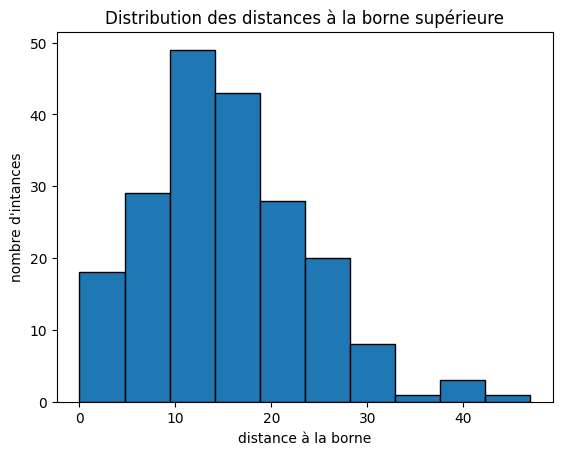

In [29]:
# A COMPLETER

Le gros des valeurs se situe entre 10 et 30. Seulement, ça ne nous dit pas grand chose.

Question 12 : Quelle information manque-t-il pour interpréter correctement la distribution des distances à la borne supérieure ?

1. Le nombre total d'instances testées
2. La valeur relative de la distance par rapport à la borne, exprimée en pourcentage
3. Le temps de calcul moyen par instance
4. Le nombre d'itérations utilisées pour chaque instance

In [ ]:
Q12 = # A COMPLETER

Pas de chance, il faut refaire les calculs !

In [30]:
random.seed(a=3)
bornes = deque(())

# on affiche la barre de progression
bar = IntProgress(min=0, max=nb_tests, layout={"width" : "100%"})
display(bar)

for _ in range(nb_tests):
    # A COMPLETER

    bornes.append(distance)
    bar.value += 1

# on cache la barre de progression
bar.close()

IntProgress(value=0, layout=Layout(width='100%'), max=200)

Text(0.5, 1.0, 'Distribution des distances à la borne supérieure')

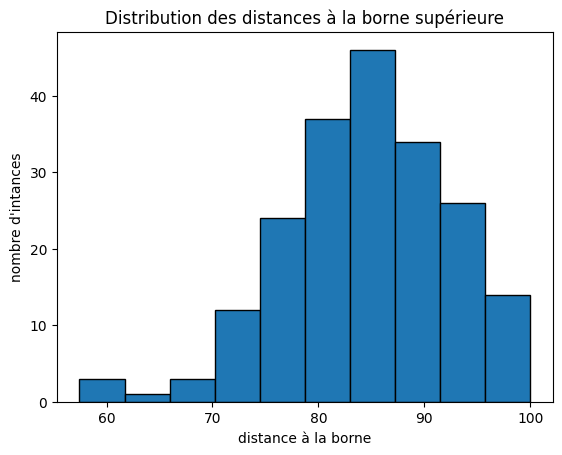

In [31]:
plt.hist(bornes, edgecolor = "black")                         
plt.xlabel("distance à la borne")                             
plt.ylabel("nombre d'intances")                               
plt.title("Distribution des distances à la borne supérieure") 

La représentation est un peu grossière, `matplotlib` a utilisé un intervalle de regroupement des valeurs trop grand. On va jouer sur le paramètre <a href="https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.hist.html"><code>bins</code></a> pour avoir une vision un peu plus précise.

Coup de chance, cette fois-ci, pas besoin de recalculer, on a déjà les valeurs dans la variable `bornes`. Il suffit de refaire un affichage de ces valeurs&nbsp;:

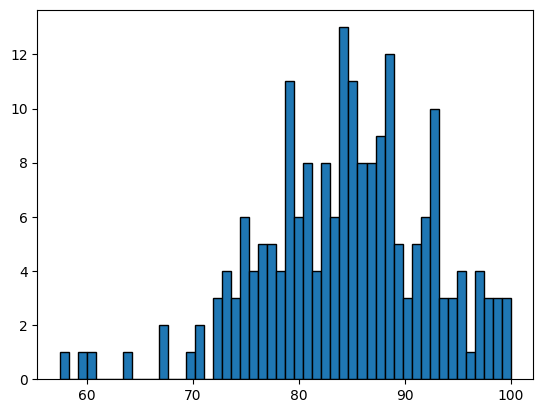

In [32]:
# A COMPLETER

Là, c'est plus lisible ! On voit bien que la grande majorité de nos solutions se situent au dessus de 70% de la borne.

Selon les performances, on pourra utiliser les fonction du module de [statistiques](https://docs.python.org/fr/3.7/library/statistics.html) standard de Python, ou les [fonctions statistiques de NumPy](https://numpy.org/doc/stable/reference/routines.statistics.html).


In [33]:
import statistics
import numpy as np

print("médiane={:.2f}"# A COMPLETER
print("moyenne={:.2f}, écart-type={:.2f}"# A COMPLETER

médiane=84.76
moyenne=84.37, écart-type=7.89


Comment interprétez-vous ces résultats&nbsp;?

<em>À COMPLÉTER</em>


Question 13 : Quelles statistiques descriptives sont les plus adaptées pour résumer le comportement d'une métaheuristique sur un ensemble d'instances ?

1. Le minimum et le maximum des valeurs obtenues
2. La moyenne associée à l'écart-type, ou la médiane, pour caractériser à la fois la tendance centrale et la dispersion des résultats
3. Uniquement la valeur médiane, car elle est insensible aux valeurs extrêmes
4. Le nombre d'instances pour lesquelles l'algorithme a trouvé la borne supérieure

In [ ]:
Q13 = # A COMPLETER

Question 14 : Pourquoi la moyenne est-elle préférable à la médiane dans ce contexte d'évaluation d'une métaheuristique ?

1. Car la moyenne est toujours plus facile à calculer que la médiane
2. Car on peut lui associer l'écart-type, ce qui permet de caractériser également la dispersion des valeurs autour de la tendance centrale
3. Car la médiane est sensible aux valeurs aberrantes contrairement à la moyenne
4. Car la moyenne garantit une meilleure stabilité numérique que la médiane

In [ ]:
Q14 = # A COMPLETER

## 3.2 Optimisation des paramètres de l'algorithme

On a bien vu tout à l'heure que changer la taille de la liste tabou jouait, mais qu'il fallait ajuster le nombre d'itération en fonction. La question qu'on peut se poser, c'est&nbsp;: quel nombre d'itération est optimal pour une taille donnée de la liste tabou&nbsp;? Et maintenant qu'on sait mesure la qualité d'une solution, on va pouvoir répondre à cette question.

Pour répondre à cette question, on va regarder l'impact de la taille de la liste tabou sur la qualité. Le but va être d'afficher avec Matplotlib la moyenne sous la forme d'une courbe, et l'écart-type par une "bande" entourant la courbe : 

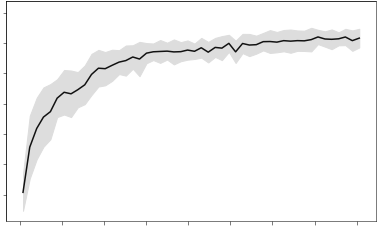



<blockquote class="comment">
<strong style="text-decoration:underline;display:block">Méthodologie</strong>
On va fixer un nombre d'itérations, faire varier la taille de la liste tabou, et calculer pour chaque configuration (chaque combinaison de nombre d'itérations et de taille de liste) la qualité moyenne et son écart-type.

Pour afficher la bande correspondant à l'écart-type, on va utiliser la fonction `fill_between` (déjà utilisée pour la résolution graphique d'un programme linéaire). Les limites de la surface à afficher seront simplement obtenues en additionnant (limite haute) ou soustrayant (limite basse) les écarts-types aux valeurs moyennes. Le code pour l'affichage est fourni.
    
Pour le reste, le principe est quasiment le même qu'avant, il faudra juste faire une double boucle imbriquée. On repart du premier paramétrage du nombre d'itérations (20) pour aller un peu plus vite, et on fait varier la taille de la liste tabou de 1 à 20. Les calculs étant un peu plus longs, on va baisser le nombre de tests par configuration à 100.

Par contre, petit détail&nbsp;: comme cette fois on va avoir une double boucle imbriquée (d'où le temps de calcul rallongé), il va falloir calculer le nombre d'étapes de la barre de progression&nbsp;!
</blockquote>

IntProgress(value=0, layout=Layout(width='100%'), max=3900)

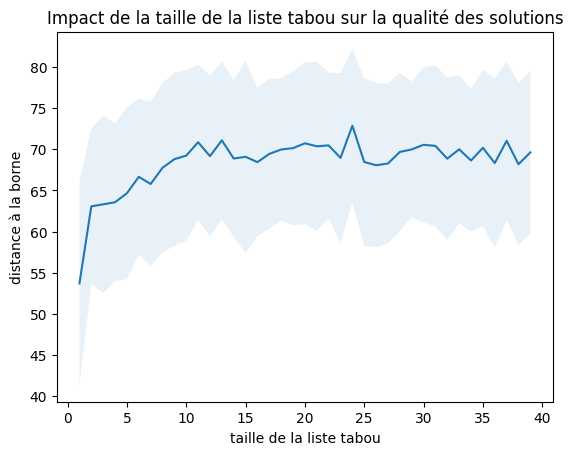

In [35]:
random.seed(a=3)

# paramètres du test
tabou_min = 1
tabou_max = 40
nb_objets = 200

nb_test  = 100
iter_max = 20

# on affiche la barre de progression
nb_steps_bar = # A COMPLETER
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)

# pour stocker les résultats
moyennes   = []
deviations = []

random.seed(a=3)

# cette fois on boucle sur la taille de la liste tabou
# A COMPLETER

# on cache la barre de progression
bar.close()

# affichage de la courbe de moyenne
plt.plot(range(tabou_min, tabou_max), moyennes)

# affichage de la bande d'écart-type
plt.fill_between(range(tabou_min, tabou_max),
                 np.subtract(moyennes, deviations), # borne haute
                 np.add(moyennes, deviations),      # borne basse
                 alpha=.1)                          # transparence
plt.xlabel("taille de la liste tabou")
plt.ylabel("distance à la borne")
plt.title("Impact de la taille de la liste tabou sur la qualité des solutions")
plt.show()

Question 15 : Que se passe-t-il lorsqu'on augmente la taille de la liste tabou au-delà d'un certain seuil sans augmenter le nombre d'itérations ?

1. La qualité des solutions continue de s'améliorer indéfiniment
2. La qualité se stabilise car la liste n'a pas le temps de se remplir, et on rallonge inutilement le temps de calcul
3. La qualité des solutions se dégrade car trop de mouvements sont interdits
4. L'algorithme diverge et ne trouve plus de solution réalisable

In [ ]:
Q15 = # A COMPLETER

Cela ouvre des perspectives pour continuer les tests, et en tirer des conclusions sur les paramètres les plus efficaces de l'algorithme. 

Question 16 : Comment procéder pour trouver le meilleur paramétrage d'une Recherche Tabou ?

1. Fixer arbitrairement la taille de la liste tabou à la moitié du nombre d'objets
2. Tester toutes les combinaisons possibles de taille de liste tabou et de nombre d'itérations jusqu'à l'optimum global
3. Tester différentes combinaisons taille de liste / nombre d'itérations sur un ensemble d'instances, et en déduire une relation fonctionnelle entre ces paramètres
4. Utiliser uniquement le multi-start pour compenser un mauvais paramétrage

In [ ]:
Q16 = # A COMPLETER

Si on veut vérifier ça de manière automatique... ! 

Question 17 : Comment peut-on déterminer automatiquement le seuil de stabilisation de la qualité en fonction de la taille de la liste tabou ?

1. En arrêtant l'algorithme dès que la meilleure solution ne change plus pendant 10 itérations
2. En définissant un seuil de variation en pourcentage en dessous duquel on considère que la qualité ne s'améliore plus significativement
3. En comparant chaque solution à la borne supérieure et en s'arrêtant dès qu'on l'atteint
4. En fixant le nombre d'itérations égal à la taille de la liste tabou

In [ ]:
Q17 = # A COMPLETER

## 3.3 Impact des paramètres d'instance

Mais finalement, on veut améliorer les performances sur ces instances difficiles, alors qu'on ne sait même pas ce qui les rend compliquées à résoudre. Du coup, la question qu'on peut se poser, c'est&nbsp;: qu'est-ce qui rend une instance difficile&nbsp;?

Pour commencer, on va jouer sur le nombre d'objets, c'est ce qu'il y a de plus simple à implémenter.


IntProgress(value=0, layout=Layout(width='100%'), max=3000)

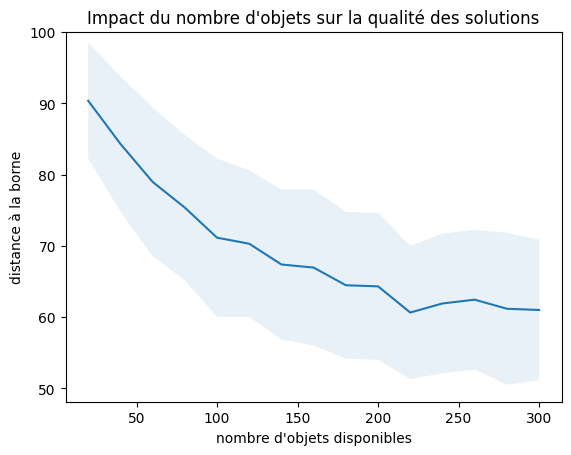

In [36]:
random.seed(a=3)

# paramètres du test
objets_min   = 20
objets_max   = 320
objets_steps = 20
nb_test      = 200

taille_tabou = 5
iter_max     = taille_tabou*2

nb_steps_bar = # A COMPLETER

# on affiche la barre de progression
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)

# pour stocker les résultats
moyennes   = []
deviations = []

# on fait varier le nombre d'objets dans la génération aléatoire d'instances 
#À COMPLÉTER

# on cache la barre de progression
bar.close()

# affichage de la courbe de moyenne
plt.plot(range(objets_min, objets_max, objets_steps), moyennes)

# affichage de la bande d'écart-type
plt.fill_between(range(objets_min, objets_max, objets_steps),
                 np.subtract(moyennes, deviations), # borne haute
                 np.add(moyennes, deviations),      # borne basse
                 alpha=.1)                          # transparence
plt.ylim(top=100)
plt.xlabel("nombre d'objets disponibles")
plt.ylabel("distance à la borne")
plt.title("Impact du nombre d'objets sur la qualité des solutions")
plt.show()

Que pensez-vous de ces résultats&nbsp;? Comment les interprétez-vous&nbsp;?

<em>À COMPLÉTER</em>


## 3.4 Pour aller plus loin

Il y a encore beaucoup de choses qu'on pourrait étudier pour comprendre et surtout améliorer le fonctionnement de notre algorithme (sans compter les calculs de vous devriez peut-être refaire avec un plus grand nombre de tests par configuration). On n'a regardé que des paramètres seuls, pas la manière dont ils peuvent se combiner (ou très peu). Et puis on ne s'est pas du tout penchés sur le temps de calcul. Comme lorsqu'on étudiait la complexité théorique des algorithmes, mesurer le temps d'occupation CPU ne sera pas forcément pertinent. Quelle métrique vous semble avoir du sens&nbsp;?

<em>À COMPLÉTER</em>

En tous cas, ça nous a permis d'améliorer la qualité de la solution en affinant les paramètres de la recherche tabou pour renforcer la phase de diversification (qui ici semblait nous poser problème). Si on rencontrait des instances plus difficiles, que notre algorithme n'arrive pas à résoudre efficacement, quel que soit le paramétrage, que pourrions-nous faire&nbsp;?

<em>À COMPLÉTER</em>

Et puis une fois tout ce travail fait (et pas avant), on pourrait aussi regarder le multi-start. Qu'est-ce qui vous semble pertinent&nbsp;?

<em>À COMPLÉTER</em>


# 4 Conclusion

Ce Workshop est maintenant terminé, et on a une idée beaucoup plus précise du comportement de notre métaheuristique.



Et si on fait un peu attention, cette étude expérimentale qu'on a effectuée est organisée comme un [plan d'expériences](https://fr.wikipedia.org/wiki/Plan_d%27exp%C3%A9riences) (par exemple, le fait de considérer la recherche simple avant de pouvoir se pencher sur le multi-start, ou la définition d'un indicateur de qualité en premier lieu). Il faudra réfléchir à un plan similaire pour votre projet, de manière à ne pas perdre de temps (d'autant que les calculs sont plutôt longs). Par contre, ne poussez pas la démarche jusqu'à appliquer les principes mathématiques mentionnés dans le lien précédent, ce sont des outils rarement utilisés tel quel dans le domaine de l'évaluation d'algorithmes.


Vous avez maintenant toutes les armes pour, non seulement concevoir et implémenter une métaheuristique, mais aussi analyser son comportement et optimiser ses paramètres pour en tirer le meilleur.